# Proyecto 1

### Universidad de Medellin
### Facultad de ingenierias
### Ingenieria financiera
### Autores: Joseph Garcia Llano y Jaime Castro  

## Itaú Unibanco Stock Data 2002-2026
Este conjunto de datos pertenece al dominio de las finanzas, la economía bursátil y el mercado de valores. Específicamente, contiene un registro histórico diario de las cotizaciones de las acciones de Itaú Unibanco (uno de los bancos más grandes de Brasil y América Latina) que cotiza en la Bolsa de Valores de Nueva York (NYSE) bajo el símbolo (Ticker) ITUB. Los datos abarcan un período de poco más de 24 años, desde febrero de 2002 hasta marzo de 2026.
<br>
* Utilidad:
  * Adecuado para enfoques de modelado de series temporales como ARIMA, LSTM y otras técnicas de pronóstico.
  * Evaluación de la volatilidad del mercado bursátil, identificación de tendencias a largo plazo y evaluación de liquidez basada en el volumen de negociación.
  * Es ideal para entrenar arquitecturas algorítmicas con el propósito de predecir el comportamiento futuro de la acción usando modelos estadísticos clásicos o redes neuronales avanzadas.

* Descripción de las Variables:
  * Date (Fecha): La fecha exacta en que ocurrió la jornada bursátil.
  * Open (Apertura): El precio en dólares (USD) de la acción al inicio de la jornada de mercado.
  * High (Máximo): El precio de negociación más alto alcanzado durante ese día.
  * Low (Mínimo): El precio de negociación más bajo registrado durante el día.
  * Close (Cierre): El precio de la acción en el momento exacto en que cerró el mercado bursátil.
  * Volume (Volumen): La cantidad total de acciones de Itaú (ITUB) negociadas a lo largo de esa jornada.
* Variable de salida:
  * Precio de cierre del dia siguiente

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv(
    '/content/Ita Unibanco Historical Stock Data (2002-2026).csv',
    sep=';'
    )

data.head(10)

,Date,Open,High,Low,Volume,Close,Precio de cierre del dia siguiente
0,25/02/2002,"0,978","1,016","0,978",2452314,"1,016","1,049"
1,26/02/2002,"1,01","1,052","1,003",28467421,"1,049","1,047"
2,27/02/2002,"1,05","1,052","1,032",9613757,"1,047","1,034"
3,28/02/2002,"1,038","1,038","1,033",13520310,"1,034","1,011"
4,1/03/2002,"1,032","1,032","0,998",3570432,"1,011","1,019"
5,4/03/2002,"1,016","1,019","1,005",720260,"1,019","0,966"
6,5/03/2002,"1,016","1,018","0,963",2850172,"0,966","0,956"
7,6/03/2002,"0,951","0,96","0,939",2239666,"0,956","0,97"
8,7/03/2002,"0,975","0,975","0,96",1546844,"0,97","0,969"
9,8/03/2002,"0,973","0,973","0,964",463024,"0,969","0,963"


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6048 entries, 0 to 6047
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Date                                6048 non-null   object
 1   Open                                6048 non-null   object
 2   High                                6048 non-null   object
 3   Low                                 6048 non-null   object
 4   Volume                              6048 non-null   int64 
 5   Close                               6048 non-null   object
 6   Precio de cierre del dia siguiente  6047 non-null   object
dtypes: int64(1), object(6)
memory usage: 330.9+ KB


In [ ]:
data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y')
data.head()

,Date,Open,High,Low,Volume,Close,Precio de cierre del dia siguiente
0,2002-02-25,"0,978","1,016","0,978",2452314,"1,016","1,049"
1,2002-02-26,"1,01","1,052","1,003",28467421,"1,049","1,047"
2,2002-02-27,"1,05","1,052","1,032",9613757,"1,047","1,034"
3,2002-02-28,"1,038","1,038","1,033",13520310,"1,034","1,011"
4,2002-03-01,"1,032","1,032","0,998",3570432,"1,011","1,019"


In [ ]:
columns_to_convert = ['Open', 'High', 'Low', 'Close', 'Precio de cierre del dia siguiente']

for col in columns_to_convert:
    data[col] = data[col].str.replace(',', '.', regex=False).astype(float)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6048 entries, 0 to 6047
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Date                                6048 non-null   datetime64[ns]
 1   Open                                6048 non-null   float64       
 2   High                                6048 non-null   float64       
 3   Low                                 6048 non-null   float64       
 4   Volume                              6048 non-null   int64         
 5   Close                               6048 non-null   float64       
 6   Precio de cierre del dia siguiente  6047 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 330.9 KB


In [ ]:
data.describe()

,Date,Open,High,Low,Volume,Close,Precio de cierre del dia siguiente
count,6048,6048.000000,6048.000000,6048.000000,6.048000e+03,6048.000000,6047.000000
mean,2014-02-26 11:19:02.857142784,4.665952,4.730389,4.598073,2.610428e+07,4.666601,4.667204
min,2002-02-25 00:00:00,0.349000,0.364000,0.343000,2.057900e+04,0.354000,0.354000
25%,2008-02-26 18:00:00,3.585000,3.654000,3.515000,1.289728e+07,3.588000,3.589500
50%,2014-02-27 12:00:00,4.927000,5.006500,4.859500,2.310523e+07,4.944500,4.945000
75%,2020-03-02 06:00:00,6.057250,6.133250,5.972000,3.529735e+07,6.054000,6.054000
max,2026-03-09 00:00:00,9.520000,9.600000,9.415000,2.059422e+08,9.570000,9.570000
std,NaN,1.927421,1.947064,1.905199,1.882137e+07,1.927707,1.927295


In [ ]:
data.isnull().sum().sort_values(ascending=False).head(16)

,0
Precio de cierre del dia siguiente,1
Open,0
Date,0
High,0
Low,0
Volume,0
Close,0


### Descripcion de los datos

  * El conjunto de datos contiene 6048 filas y 7 columnas.
  * La variable Date corresponde a una fecha. La variable Volume correspondea una variable de tipo int64 ya que representa una cantidad entera de acciones. Las demas variables corresponden a float64, indicando que son variables de tipo numerico continuo.

array([[<Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'High'}>],
       [<Axes: title={'center': 'Low'}>,
        <Axes: title={'center': 'Close'}>],
       [<Axes: title={'center': 'Volume'}>,
        <Axes: title={'center': 'Precio de cierre del dia siguiente'}>]],
      dtype=object)

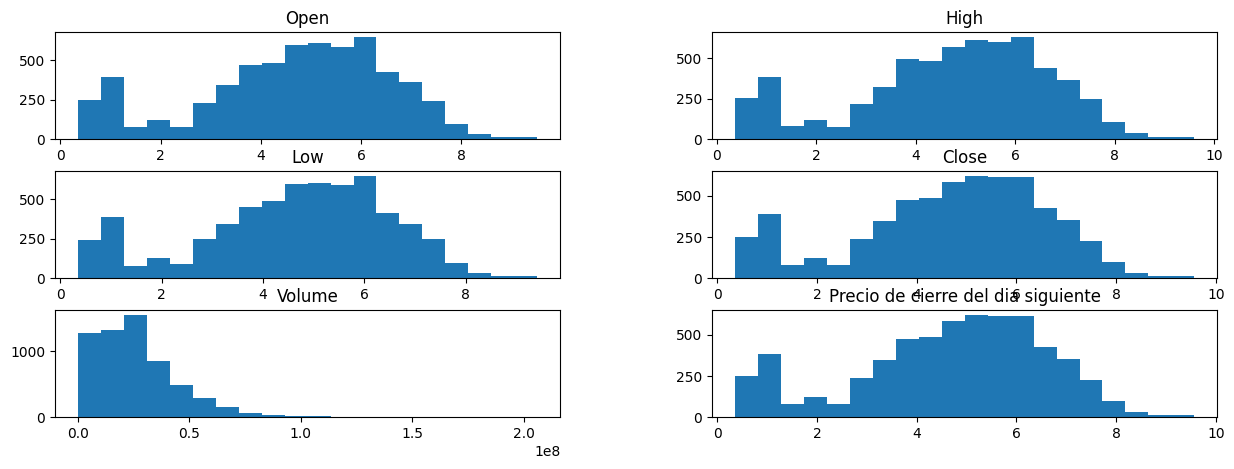

In [ ]:
data[['Open', 'High','Low','Close','Volume',"Precio de cierre del dia siguiente"]].hist(
    figsize=(15, 5),
    bins=20,
    grid=False
    )

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>]], dtype=object)

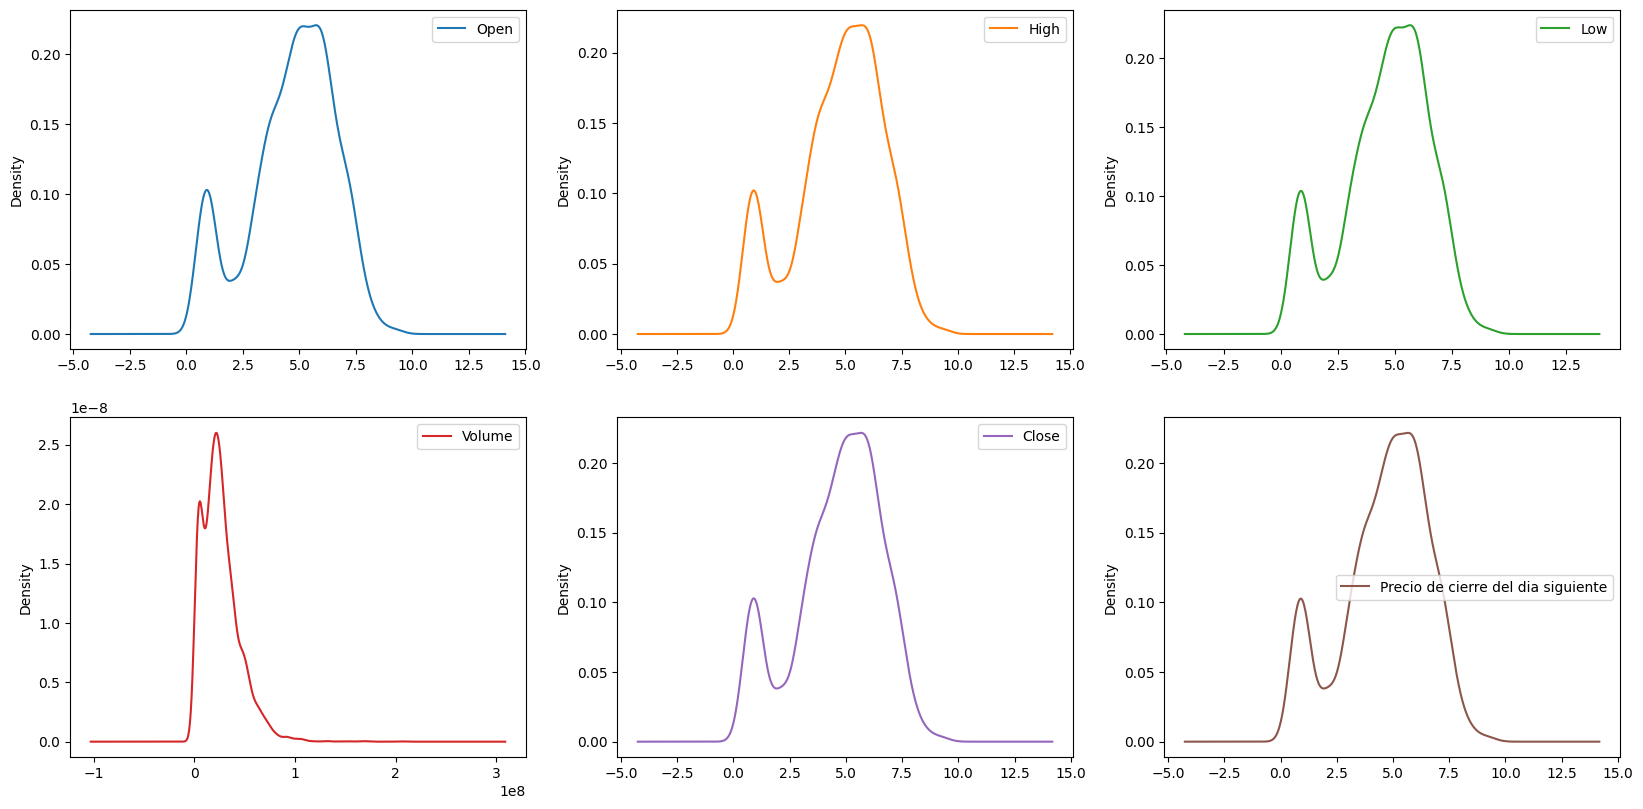

In [ ]:
data.select_dtypes(include=['int64', 'float64']).plot(
    kind='kde',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

,0
Open,"Axes(0.125,0.653529;0.227941x0.226471)"
High,"Axes(0.398529,0.653529;0.227941x0.226471)"
Low,"Axes(0.672059,0.653529;0.227941x0.226471)"
Volume,"Axes(0.125,0.381765;0.227941x0.226471)"
Close,"Axes(0.398529,0.381765;0.227941x0.226471)"
Precio de cierre del dia siguiente,"Axes(0.672059,0.381765;0.227941x0.226471)"


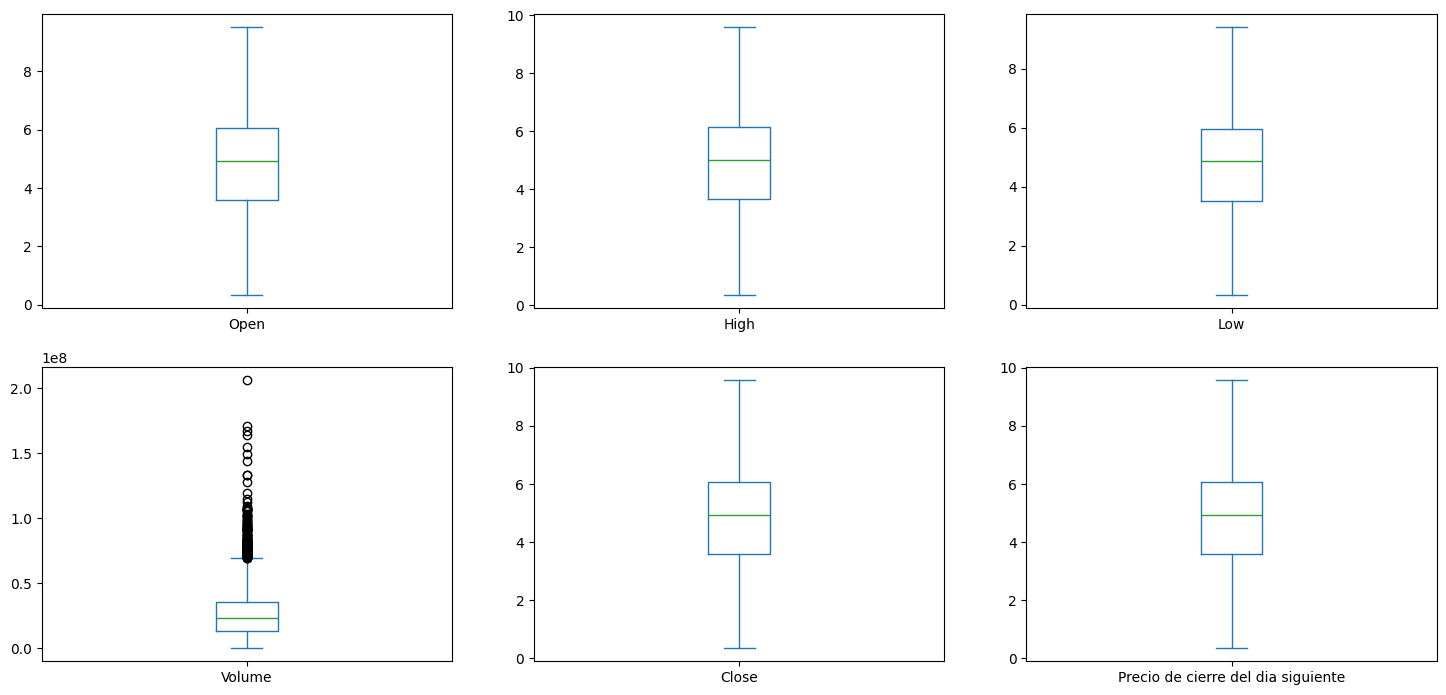

In [ ]:
data.select_dtypes(include=['int64', 'float64']).plot(
    kind='box',
    figsize=(18, 13),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

### Resumen de las Variables Numéricas

A continuación, se presenta un análisis de la distribución de cada variable numérica, basándose en los histogramas y diagramas de caja (box plots) generados previamente.


#### Open (Precio de Apertura)


- **Distribución y Sesgo:** La distribución del precio de apertura muestra un patrón multimodal, con picos significativos alrededor de 1-2 USD y otro pico más amplio entre 5-7 USD. Esto sugiere que el precio de apertura ha fluctuado en diferentes rangos a lo largo del tiempo, posiblemente reflejando diferentes períodos de cotización o cambios en el valor de la acción.


#### High (Precio Máximo)

- **Distribución y Sesgo:** Similar al precio de apertura, el precio máximo diario también exhibe una distribución multimodal con picos en rangos similares (1-2 USD y 5-7 USD). Esto es esperado, ya que los precios máximos suelen seguir la misma tendencia general que los precios de apertura.


#### Low (Precio Mínimo)

- **Distribución y Sesgo:** La distribución del precio mínimo diario también es multimodal, siguiendo el patrón de 'Open' y 'High'. Los picos se observan en los mismos rangos de precios bajos y altos, lo que sugiere que los precios mínimos también reflejan las diferentes fases de la cotización de la acción.


#### Close (Precio de Cierre)

- **Distribución y Sesgo:** La distribución del precio de cierre es, como era de esperar, muy similar a las otras variables de precio, con una naturaleza multimodal y picos en los mismos rangos. Esto indica que el precio de cierre también ha experimentado variaciones significativas a lo largo del tiempo, reflejando las tendencias generales del mercado.


#### Volume (Volumen de Negociación)

- **Distribución y Sesgo:** El volumen de negociación presenta una distribución muy asimétrica con un sesgo fuerte hacia la derecha. La mayoría de los días tienen un volumen de negociación bajo a moderado, mientras que hay un número menor de días con volúmenes extremadamente altos. El histograma muestra un pico pronunciado cerca de cero y una cola larga hacia la derecha.
- **Diagrama de Cajas y Bigotes:** El box plot de 'Volume' muestra una mediana relativamente baja. La caja es pequeña, lo que indica que la mayor parte del volumen se concentra en un rango bajo. Sin embargo, hay una gran cantidad de valores atípicos (outliers) que se extienden muy por encima del bigote superior. Estos outliers representan días con un volumen de negociación excepcionalmente alto, lo cual es común en los mercados financieros durante eventos noticiosos o periodos de alta volatilidad.

#### Precio de cierre del dia siguiente (Target Variable)

- **Distribución y Sesgo:** Esta variable, que es el objetivo de predicción, tiene una distribución y un sesgo casi idénticos a la variable 'Close'. Esto es lógico, ya que el precio de cierre del día siguiente es, en esencia, el precio de cierre en un momento futuro. Muestra la misma multimodalidad y picos en los mismos rangos de precios.


## Regresion lineal por minimos cuadrados ordinarios

In [ ]:
from sklearn.linear_model import LinearRegression

X = data.iloc[:-1, 1:6].to_numpy()
#print(X)

y = data.iloc[:-1, 6]
#print(y)

reg = LinearRegression().fit(X, y)

print(reg.score(X, y)) #Ajuste-R^2

print(reg.coef_)

print(reg.intercept_)

print(reg.predict(np.array([[8.13, 8.348, 8.07, 40223100, 8.29]])))

0.9958716928330383
[-1.35576660e-01  1.69757497e-01  1.35288443e-01  1.15406934e-10
  8.28013959e-01]
0.008288147437233384
[8.28384097]


0.9958558467970963
[0.99792138]
0.01090177608569931
[8.28366998]


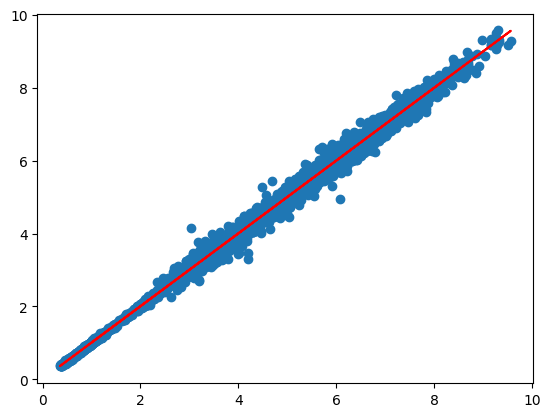

In [ ]:
import matplotlib.pyplot as plt

x = data["Close"][:-1].to_numpy().reshape(-1,1)
#y = y.to_numpy()
reg = LinearRegression().fit(x, y)

print(reg.score(x, y))

print(reg.coef_)

print(reg.intercept_)

print(reg.predict(np.array([8.29]).reshape(-1,1)))


plt.scatter(x,y)
plt.plot(x,(reg.coef_*x+reg.intercept_), "r")
plt.show()

* El R² es prácticamente idéntico entre ambos modelos. Agregar Open, High, Low y Volume no mejora en absoluto la capacidad explicativa del modelo.
* Ambos modelos apuntan a la misma conclusión: la pendiente univariada (≈0.998) e intercepto (≈0.011) muestran que el mejor predictor lineal de "cierre de mañana" es simplemente "cierre de hoy"
* El modelo multivariado sufre de multicolinealidad: Open, High, Low y Close describen esencialmente la misma jornada bursátil.
* El coeficiente de Volume es prácticamente cero (1.15e-10) en su escala natural — el volumen negociado aporta información casi nula para predecir el precio, comparado con las variables de precio.<br>
→ Ambos modelos describen la misma relación, pero el modelo univariado es preferible por parsimonia.
<table>
  <tr>
    <th></th>
    <th>Univariada</th>
    <th>Multivariada</th>
  </tr>
    
 <tr>
    <td>R^2</td>
    <td>0.99586</td>
    <td>0.99587</td>
  </tr>
  <tr>
    <td>Coeficiente(s)</td>
    <td>0.998 (Close)</td>
    <td>-0.136 (Open), 0.170 (High), 0.135 (Low), ~0 (Vol), 0.828 (Close)</td>
  </tr>
  <tr>
    <td>Intercepto</td>
    <td>0.0109</td>
    <td>0.0083</td>
  </tr>
</table>

## Gradiente descendiente

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from __future__ import division

#Sigmoidal
def sigmoidal(z):

    s = 1/(1 + np.exp(-z))

    return s

#Error cuadrático medio (criterio para el modelo de regresión polinomial)
def ECM(Y_est,Y):
    N = np.size(Y)
    ecm = sum((Y_est - Y)**2)/(2*N)
    return ecm

#Modelo Regresión Múltiple
def regression(X, W):
    Yest = np.dot(X,W)    #con np.dot se realiza el producto matricial. Aquí X es dim [Nxd] y W es dim [dx1]
    return Yest           #La variable Yest contiene la salida de f(X,W)


#Potencia de polinomio
def potenciaPolinomio(X,grado):
    """
    Este método permite aumentar la matriz (base de datos de entrenamiento)
    de tal manera que se incluyan los términos con potencia mayores que 1
    de acuerdo al parámetro grado (M) que pase el usuario.
    """
    X2 = X

    if grado != 1:
        for i in range(2,grado+1):
            Xadd = X**i
            X2 = np.concatenate((X2, Xadd), axis=1)

    return X2


#Gradiente descendente para regresión polinomial
def gradiente_descendente(X,Y,grado,eta,iterations):

    """
    params:
    X: base de datos de entrenamiento (array de numpy)
    Y: variable de salida (array de numpy)
    grado: grado del polinomi (Natural mayor o igual a 1)
    eta: tasa de aprendizaje para el algoritmo de gradiente descendente
    (real mayor que cero. Ej: 0.001)
    iterations: número de iteraciones del algoritmo de gradiente descendente
    """

    #Se modifica la matriz de datos original de acuerdo al grado del polinomio ingresado para el modelo
    X = potenciaPolinomio(X,grado)

    #X es la matriz de datos extendida. W es el vector de parámetros del modelo
    #Extendemos la matriz
    unos = np.array([np.ones(np.size(X,0))])
    #Concatenamos el vector de unos con la matriz X
    X = np.concatenate((unos.T, X), axis=1)
    X = X.reshape(np.size(X,0),np.size(X,1))

    Y = Y.reshape(np.size(Y), 1)

    #Tomamos el número de variables del problema
    d = np.size(X,1)

    #Tomamos el número de muestras de la base de datos
    N = np.size(X,0)

    #Inicializamos el vector de parámetros aleatoriamente
    Want = np.zeros(d)
    Want = Want.reshape(np.size(Want),1)
    #print(Want)

    eta = eta

    iteraciones = iterations
    ecms = np.zeros(iteraciones)

    for iter in range(iteraciones):

        error = ECM(regression(X,Want),Y)
        ecms[iter] = error


        W = Want - (eta * 1/N * np.dot(X.T, (regression(X,Want) - Y)))
        Want = W


    print ('Vector de parámetros del modelo:\n')
    print (W)
    print ('\nError Final = ' + str(np.min(ecms)))


    plt.plot(ecms)
    plt.show()

    return W


In [ ]:
from sklearn.preprocessing import MinMaxScaler

data = data.dropna(subset=['Precio de cierre del dia siguiente']).reset_index(drop=True)


features = ['Open', 'High', 'Low', 'Volume', 'Close']
target = 'Precio de cierre del dia siguiente'

X = data[features].to_numpy()
Y = data[target].to_numpy()

# Partición CRONOLÓGICA (sin mezclar/shuffle): 80% más antiguo para train,
# 20% más reciente para test, tal como corresponde en series de tiempo.
n = len(data)
train_size = int(n * 0.8)

X_train_raw, X_test_raw = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

# Escalado: el scaler se AJUSTA solo con train para evitar fuga de información (leakage);
# test solo se transforma con esos mismos parámetros.
scaler = MinMaxScaler()
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')

Train: 4837 filas | Test: 1210 filas


/tmp/ipykernel_1449/261414118.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ecms[iter] = error


Vector de parámetros del modelo:

[[0.3533266 ]
 [2.04531086]
 [2.07712261]
 [2.05844784]
 [0.16393695]
 [2.0830058 ]]

Error Final = 0.009257725315797554


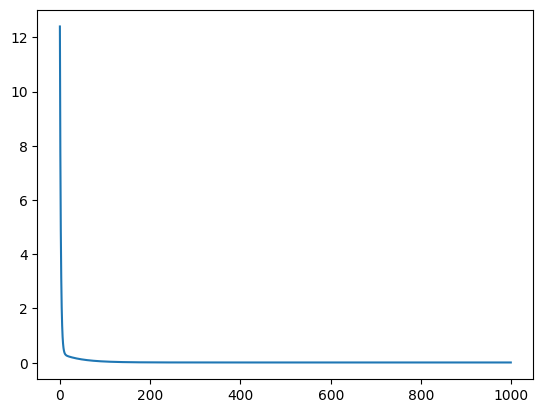

In [ ]:
eta = 0.1
grado = 1
iterations = 1000

W = gradiente_descendente(X_train,Y_train,grado,eta,iterations)

## Malla de valores

<table>
  <tr>
    <th>Tasa de aprendizaje</th>
    <th>Grado del polinomio</th>
    <th>Error Cuadrático Medio (ECM)</th>
  </tr>
    
 <tr>
    <td>0.1</td>
    <td>1</td>
    <td>0.00925</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>2</td>
    <td>0.01502</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>3</td>
    <td>0.01140</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>4</td>
    <td>0.01056</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>5</td>
    <td>0.01123</td>
  </tr>
  
  <tr>
    <td>0.1</td>
    <td>6</td>
    <td>0.01212</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>7</td>
    <td>0.01280</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>8</td>
    <td>0.01314</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>9</td>
    <td>0.01321</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>10</td>
    <td>0.01308</td>
  </tr>
</table>

In [ ]:
#X es la matriz de datos extendida. W es el vector de parámetros del modelo
#Extendemos la matriz
unos = np.array([np.ones(np.size(X_test,0))])
#Concatenamos el vector de unos con la matriz X
X_test = np.concatenate((unos.T, X_test), axis=1)
X_test = X_test.reshape(np.size(X_test,0),np.size(X_test,1))


In [ ]:
X_test.shape

(1210, 6)

In [ ]:
W.shape

(6, 1)

In [ ]:
ypred = regression(X_test, W)
ypred.shape

(1210, 1)

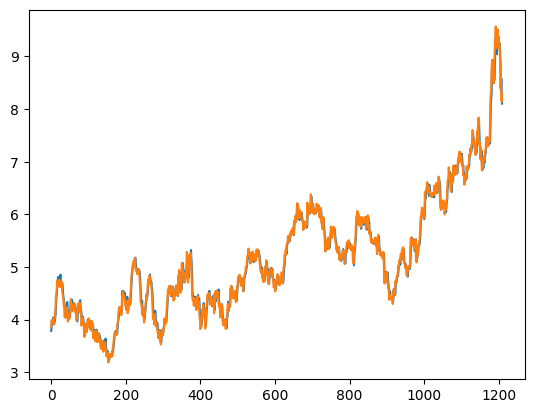

In [ ]:
plt.plot(ypred)
plt.plot(Y_test)
plt.show()

* El error no mejora con el grado del polinomio. El mínimo global está en grado = 1, sube fuerte en grado = 2, baja un poco hacia grado = 3–4, y luego empeora hasta grado = 9. Este patrón sucede cuando el polinomio de mayor grado no aporta señal real: las variables (Open, High, Low, Close) ya están altamente correlacionadas entre sí, elevarlas a potencias solo agrega redundancia y ruido numérico al gradiente, sin capturar ninguna no linealidad genuina en los datos.

* El precio de mañana depende casi linealmente del precio de hoy, y agregar potencias solo introduce parámetros redundantes y mayor riesgo de inestabilidad numérica sin beneficio real.
<br>
→ El modelo que mejor predice es el de grado = 1, η = 0.1, tanto por tener el menor ECM de toda la malla como por ser el más simple e interpretable, ademas su resultado es consistente con la solución analítica de mínimos cuadrados.